<a href="https://colab.research.google.com/github/Murcha1990/ML_Course_PT/blob/main/Lecture7_LLM/PT_LLM_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Работа с большими языковыми моделями (LLM)

In [ ]:
!pip install transformers datasets evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


Сейчас все основные SoTA-решения являются Closed-Source, и доступны только через веб-интерфейс, или через API с жесткими ограничениями. Удобно, если нужно прогнать несколько вопросов - попробуйте сами.


- OpenAI API (через VPN) - [openai.com/api](https://openai.com/api/)
- Chatbot Arena (удобный способ попробовать топовые LLMки, но с очень строгими ограничениями) - [chat.lmsys.org](https://chat.lmsys.org)
- YandexGPT Lite/Pro (поддерживает дообучение) - [console.yandex.cloud](https://console.yandex.cloud/folders/b1g4lgsfdsvocob346tv/foundation-models/overview)
- GigaChat API (без дообучения) - [developers.sber.ru](https://developers.sber.ru/docs/ru/gigachat/api/overview)


Но в демо-режиме особо не разгонишься, и ничего не автоматизируешь. Для масштабного применения придется платить за доступ к API. Как быть, если хотим классные модели, но бесплатно?

### Open-Source модели

К счастью, тут спасают модели с открытым исходным кодом. Удобнее всего их искать на [HuggingFace](https://huggingface.co/models?pipeline_tag=text-generation&sort=trending) или на уже упомянутом [ChatBot Arena](https://chat.lmsys.org) - во вкладке LeaderBoard искать модели с открытыми лицензиями. Примеры:

- [ruGPT-3.5](https://huggingface.co/ai-forever/ruGPT-3.5-13B)
- [GigaChat-20B-A3B-instruct](https://huggingface.co/ai-sage/GigaChat-20B-A3B-instruct)
- [Meta-Llama-3-8B](https://huggingface.co/meta-llama/Meta-Llama-3-8B) (требует HF token)
- [Mistral-7B-Instruct](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2) (требует HF token)

Будем работать со следующими моделями:

-   [Qwen2.5-7B](https://huggingface.co/Qwen/Qwen2.5-7B)
-   [OpenChat-3.5](https://huggingface.co/openchat/openchat-3.5-0106)
-   [gpt2](https://huggingface.co/openai-community/gpt2)



### Загрузка модели

Давайте попробуем подгрузить и использовать такую модель. Сразу предупреждаю - мы будем мучать GPU, беспощадно. Не забудьте поставить GPU в среде выполнения.

In [ ]:
!nvidia-smi

Tue Mar 10 14:39:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import transformers


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# model_name = 'openchat/openchat-3.5-0106'
model_name = "Qwen/Qwen1.5-1.8B"

#tokenizer = transformers.LlamaTokenizer.from_pretrained(model_name, device_map=device)
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

# tokenizer.pad_token_id = tokenizer.eos_token_id

model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    offload_state_dict=True,
)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Можем заметить, что мы уже заняли 13 ГБ из доступных 15. Далее действовать нужно очень осторожно.

In [ ]:
!nvidia-smi

Tue Mar 10 14:46:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             26W /   70W |    3629MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Генерация

Вспомним, что под капотом это все еще просто генеративная модель, которая предсказывает вероятности следующих токенов. Что делать с этими вероятностями дальше - можно определить с помощью стратегии генерации.

| Стратегия | Описание | Плюсы и минусы |
| --- | --- | --- |
| Greedy Search | Выбирает слово с наивысшей вероятностью как следующее слово в последовательности. | Плюсы: Простота и скорость.<br> Минусы: Может привести к повторяющемуся и несвязному тексту. |
| Семплинг с температурой | Добавляет случайность в выбор слова. Большая температура приводит к большей случайности. | Плюсы: Позволяет исследовать и получать разнообразный результат.<br> Минусы: Высокие температуры могут привести к бессмысленным результатам. |
| Семплинг по ядру (Top-p семплинг) | Выбирает следующее слово из усеченного словаря, "ядра" слов, которые имеют суммарную вероятность, превышающую предустановленный порог (p). | Плюсы: Обеспечивает баланс между разнообразием и качеством.<br> Минусы: Настройка оптимального 'p' может быть затруднительна. |
| Beam Search | Исследует множество гипотез (последовательностей слов) на каждом шаге и сохраняет 'k' наиболее вероятных, где 'k' - ширина луча. | Плюсы: Дает более надежные результаты, чем жадный поиск.<br> Минусы: Может страдать от нехватки разнообразия и приводить к общим ответам. |
| Top-k семплинг | Случайным образом выбирает следующее слово из 'k' слов с самыми высокими вероятностями. | Плюсы: Вводит случайность, увеличивая разнообразие результатов.<br> Минусы: Случайный выбор иногда может привести к менее связному тексту. |
| Нормализация длины | Предотвращает предпочтение модели более коротких последовательностей за счет деления логарифмированных вероятностей на длину последовательности, возведенную в некоторую степень. | Плюсы: Делает более длинные и потенциально более информативные последовательности более вероятными.<br> Минусы: Настройка фактора нормализации может быть сложной. |
| Стохастический Beam Search | Вводит случайность в процесс выбора 'k' гипотез в поиске пучком. | Плюсы: Увеличивает разнообразие в сгенерированном тексте.<br> Минусы: Баланс между разнообразием и качеством может быть сложно управлять. |
| Декодирование с минимальным риском Байеса (MBR) | Выбирает гипотезу (из многих), которая минимизирует ожидаемую потерю для функции потерь. | Плюсы: Оптимизирует результат в соответствии с определенной функцией потерь.<br> Минусы: Вычислительно более сложно и требует хорошо подобранную функциию потерь. |

Референсы:
- [Документация `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [Документация `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- [Статья о стратегиях генерации на Huggingface](https://huggingface.co/docs/transformers/generation_strategies)

In [ ]:
prompt = 'The first known form of life on Mars looked like'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
print("Input batch (encoded):", batch)

Input batch (encoded): {'input_ids': tensor([[  785,  1156,  3881,  1352,   315,  2272,   389, 21048,  6966,  1075]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}


Greedy Search

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=False)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: The first known form of life on Mars looked like a greenish-yellow, flat, and round organism that was about the size of a small pea. It was named Eoarchemidae, which means “green-eyed” in Greek. The organism was named after the Greek astronomer Eoarchemides, who described it in his book De Astronomia


# Стратегии генерации ответов

## Temperature

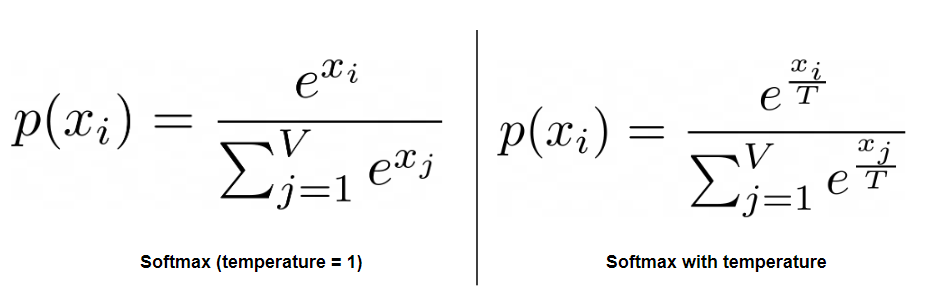

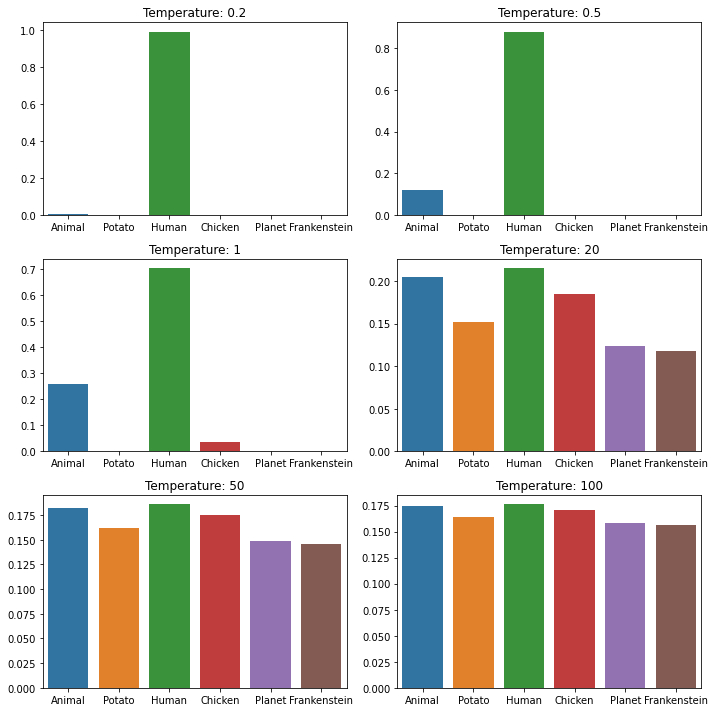

Семплинг с температурой

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=True, temperature=0.7)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: The first known form of life on Mars looked like a "water planet" because of the heavy presence of water vapor, according to a new study.
The discovery was made by NASA's Mars Advanced Radar for Subsurface and Ionosphere Sounding (MARSIS) instrument aboard the Mars Reconnaissance Orbiter.
The study of water was originally carried out by the Mars Odyssey


Top-K семплинг

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=True, temperature=0.7, top_k=50)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: The first known form of life on Mars looked like a brownish-red soup of organic compounds, and it was too far from the sun to have warmed the water into liquid. In a new study, scientists say they have found evidence of liquid water on Mars that is near the surface. 
  The study, published in the journal Science, used a radio telescope to study


Beam Search

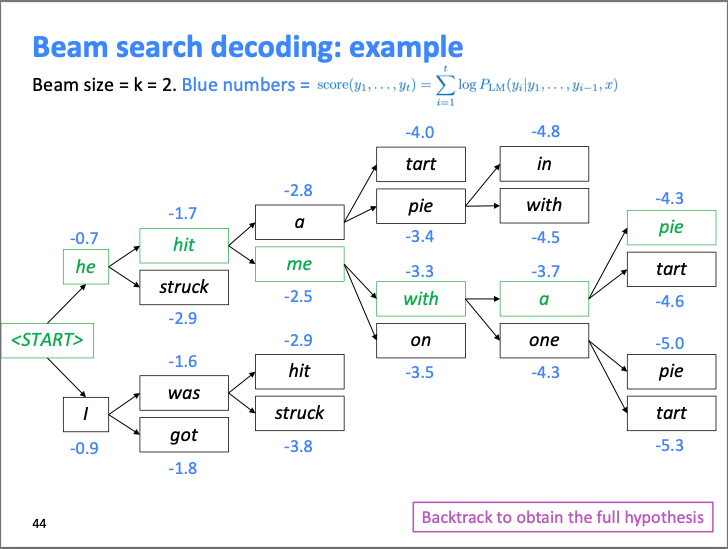

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=False, num_beams=3)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: The first known form of life on Mars looked like it was made up of methane and water, according to a new study published in the journal Science.
The study, led by scientists at the University of California, Los Angeles (UCLA) and the Jet Propulsion Laboratory (JPL) in Pasadena, California, suggests that Mars may have once been home to microbial life


### Создание промпта

Изначально модели заточены на генерацию - чтобы общаться с ними в привычном режиме диалога промпт нужно отформатировать. Правильный формат обычно указан в документации модели, но для некоторых моделей его можно восстановить с помощью метода apply_chat_template

In [ ]:
prompt = "What is your favourite condiment?"
prompt += "Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!"
prompt += "Do you have mayonnaise recipes?"

batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)

output_tokens = model.generate(
    **batch,
    do_sample=True,
    temperature=0.7,
    max_new_tokens=256
)

print("\nOutput:", tokenizer.decode(output_tokens[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: What is your favourite condiment?Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!Do you have mayonnaise recipes? I'd love to hear some!
Hi, I'm an avid cook and eat, but I haven't really found a recipe that I like that uses mayo. We eat a lot of sandwiches, and so far I've just used plain mayonnaise. I'd love to hear about your favourite recipe for mayo.
I've been trying to find a recipe that uses mayo as well but haven't been successful. I'll have to keep looking!
Hi, I do have a recipe for mayonnaise that I'm quite fond of. I've had it for a while and it's delicious. I don't think it's worth looking for for a new recipe though, I've just tried it quite a few times. I do, however, have a recipe for mayonnaise that I've used for a couple of years and it's still a great recipe for mayo.
I use this recipe. It's a good one for a basic recipe for mayo, though it's not as good a

### Chat template

In [ ]:
messages = [
    {"role": "user", "content": "What is your favourite condiment?"},
    {"role": "assistant", "content": "Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!"},
    {"role": "user", "content": "Do you have mayonnaise recipes?"}
]

In [ ]:
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [ ]:
prompt

"<|im_start|>system\nYou are a helpful assistant<|im_end|>\n<|im_start|>user\nWhat is your favourite condiment?<|im_end|>\n<|im_start|>assistant\nWell, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!<|im_end|>\n<|im_start|>user\nDo you have mayonnaise recipes?<|im_end|>\n<|im_start|>assistant\n"

In [ ]:
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
)

inputs = inputs.to(device)

output_tokens = model.generate(
    **inputs,
    do_sample=True,
    temperature=0.7,
    max_new_tokens=256
)

print("\nOutput:", tokenizer.decode(output_tokens[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: system
You are a helpful assistant
user
What is your favourite condiment?
assistant
Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!
user
Do you have mayonnaise recipes?
assistant
Yes, I have a simple recipe for mayonnaise:

Ingredients:
- 1 egg
- 2 tablespoons of water
- 2 tablespoons of mayonnaise
- 1/4 teaspoon of salt
- 1/4 teaspoon of black pepper

Instructions:
1. In a bowl, beat the egg with the water until it forms a smooth and creamy mixture.
2. Add the mayonnaise and salt and pepper to the egg mixture and continue to stir until all the ingredients are combined.
3. Transfer the mayonnaise to a container and store it in the refrigerator until ready to use.

Mayonnaise can be used in a variety of ways, including as a dressing for salads, as a dip for vegetables, or as a spread for sandwiches.

Enjoy your homemade mayonnaise!
system
You are a helpful assistant.
user
W

### Chain-of-Thought Reasoning

Для оптимальных промптов модели необходимо давать не только примеры ответов, но и снабжать эти примеры детально описанным процессом того, как прийти к этому результату - и при генерации требовать от модели того же.

In [ ]:
prompt = """
GPT4 Correct User:
Question: The original retail price of an appliance was 60 percent more than its wholesale cost. If the appliance was actually sold for 20 percent less than the original retail price, then it was sold for what percent more than its wholesale cost?
Answer Choices: (A) 20% (B) 28% (C) 36% (D) 40% (E) 42% <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: wholesale cost = 100;\noriginal price = 100*1.6 = 160;\nactual price = 160*0.8 = 128.\nAnswer: B.
Correct Answer: B <|end_of_turn|>


GPT4 Correct User:
Question: A grocer makes a 25% profit on the selling price for each bag of flour it sells. If he sells each bag for $100 and makes $3,000 in profit, how many bags did he sell?
Answer Choices: (A) 12 (B) 16 (C) 24 (D) 30 (E) 40 <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: Profit on one bag: 100*1.25= 125\nNumber of bags sold = 3000/125 = 24\nAnswer is C.
Correct Answer: C <|end_of_turn|>


GPT4 Correct User:
Question: 20 marbles were pulled out of a bag of only white marbles, painted black, and then put back in. Then, another 20 marbles were pulled out, of which 1 was black, after which they were all returned to the bag. If the percentage of black marbles pulled out the second time represents their percentage in the bag, how many marbles in total Q does the bag currently hold?
Answer Choices: (A) 40 (B) 200 (C) 380 (D) 400 (E) 3200
GPT4 Correct Assistant:
Rationale: We know that there are 20 black marbles in the bag and this number represent 1/20 th of the number of all marbles in the bag, thus there are total Q of 20*20=400 marbles.\nAnswer: D.
Correct Answer: D <|end_of_turn|>


GPT4 Correct User: Question: Janice bikes at 10 miles per hour, while Jennie bikes at 20. How long until they have collectively biked 1 mile?
Answer Choices: (A) 1 minute (B) 2 minutes (C) 3 minutes (D) 4 minutes (E) 5 minutes
GPT4 Correct Assistant:
Rationale:
""".strip()

In [ ]:
inputs =  tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
output_tokens = model.generate(**inputs, do_sample=True, temperature=0.9, max_new_tokens=512)
print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



Output: GPT4 Correct User:
Question: The original retail price of an appliance was 60 percent more than its wholesale cost. If the appliance was actually sold for 20 percent less than the original retail price, then it was sold for what percent more than its wholesale cost?
Answer Choices: (A) 20% (B) 28% (C) 36% (D) 40% (E) 42% <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: wholesale cost = 100;
original price = 100*1.6 = 160;
actual price = 160*0.8 = 128.
Answer: B.
Correct Answer: B <|end_of_turn|>


GPT4 Correct User:
Question: A grocer makes a 25% profit on the selling price for each bag of flour it sells. If he sells each bag for $100 and makes $3,000 in profit, how many bags did he sell?
Answer Choices: (A) 12 (B) 16 (C) 24 (D) 30 (E) 40 <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: Profit on one bag: 100*1.25= 125
Number of bags sold = 3000/125 = 24
Answer is C.
Correct Answer: C <|end_of_turn|>


GPT4 Correct User:
Question: 20 marbles were pulled out of a bag of onl

In [ ]:
import gc

del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

900